In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

In [2]:
df = pd.read_csv('../data/hotel_booking_clean.csv')
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Reusable Functions

## Notes

Business pov:

*  
Modelling pov:

* 

# Bivariate Analysis

## iscanceled vs lead time

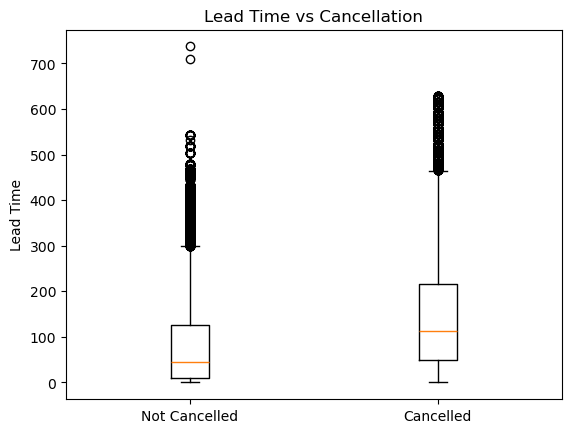

In [3]:
fig, ax = plt.subplots()

ax.boxplot(
    [
        df[df['is_canceled'] == 0]['lead_time'],
        df[df['is_canceled'] == 1]['lead_time']
    ],
    tick_labels=['Not Cancelled', 'Cancelled']
)

ax.set_title('Lead Time vs Cancellation')
ax.set_ylabel('Lead Time')
ax.set

plt.show()

In [26]:
df[df['is_canceled']==1]['lead_time'].sort_values(ascending=False)

64757     629
64756     629
64767     629
64766     629
64765     629
         ... 
88866       0
105416      0
88865       0
91037       0
101437      0
Name: lead_time, Length: 44153, dtype: int64

In [25]:
df[df['is_canceled']==0]['lead_time'].sort_values(ascending=False)

1         737
4180      709
27964     542
27962     542
27970     542
         ... 
38617       0
79690       0
113023      0
38604       0
100747      0
Name: lead_time, Length: 74744, dtype: int64

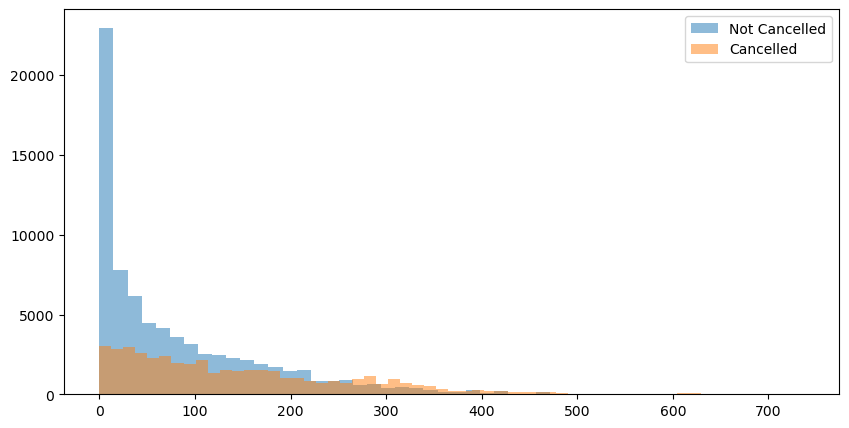

In [30]:
fig, ax = plt.subplots(figsize=(10,5))

bins_size = 50
#bins_size = np.linspace(0,500,51)

ax.hist(
    df[df['is_canceled']==0]['lead_time'],
    bins=bins_size,
    alpha=0.5,
    label='Not Cancelled'
    )

ax.hist(
    df[df['is_canceled']==1]['lead_time'],
    bins=bins_size,
    alpha=0.5,
    label='Cancelled'
    )

ax.legend()

plt.show()

## Notes

Business pov:

* Bookings with longer lead times appear more likely to result in cancellations
* Bookings that were made closer to or on the same day resulted in exceptionally successful bookings

Modelling pov:

* Concerning/Worrying regarding sparseness, the huge set of lead time could potentially be 0's
* Seems heavily imbalanced for shorter lead times,  but relatively balanced as lead time spreads out
    

## Arrival Date Year

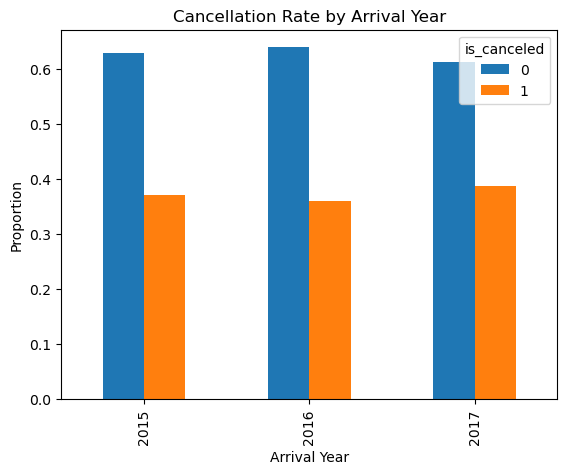

In [5]:
fig, ax = plt.subplots()

pd.crosstab(
    df['arrival_date_year'],
    df['is_canceled'],
    normalize='index'
).plot(
    kind='bar',
    ax=ax
)

ax.set_title('Cancellation Rate by Arrival Year')
ax.set_xlabel('Arrival Year')
ax.set_ylabel('Proportion')

plt.show()

## Notes

Business pov:

* Bookings cancellation rate stays stable across yearly, showing little to none impact by years. Though, only three years are only available in the dataset. Perphaps if more years were present a different trend could showcase

Modelling pov:

* No good predictive signal. All three years reflects the same insights and meaning 

## Arrival Month and Arrival Week Number

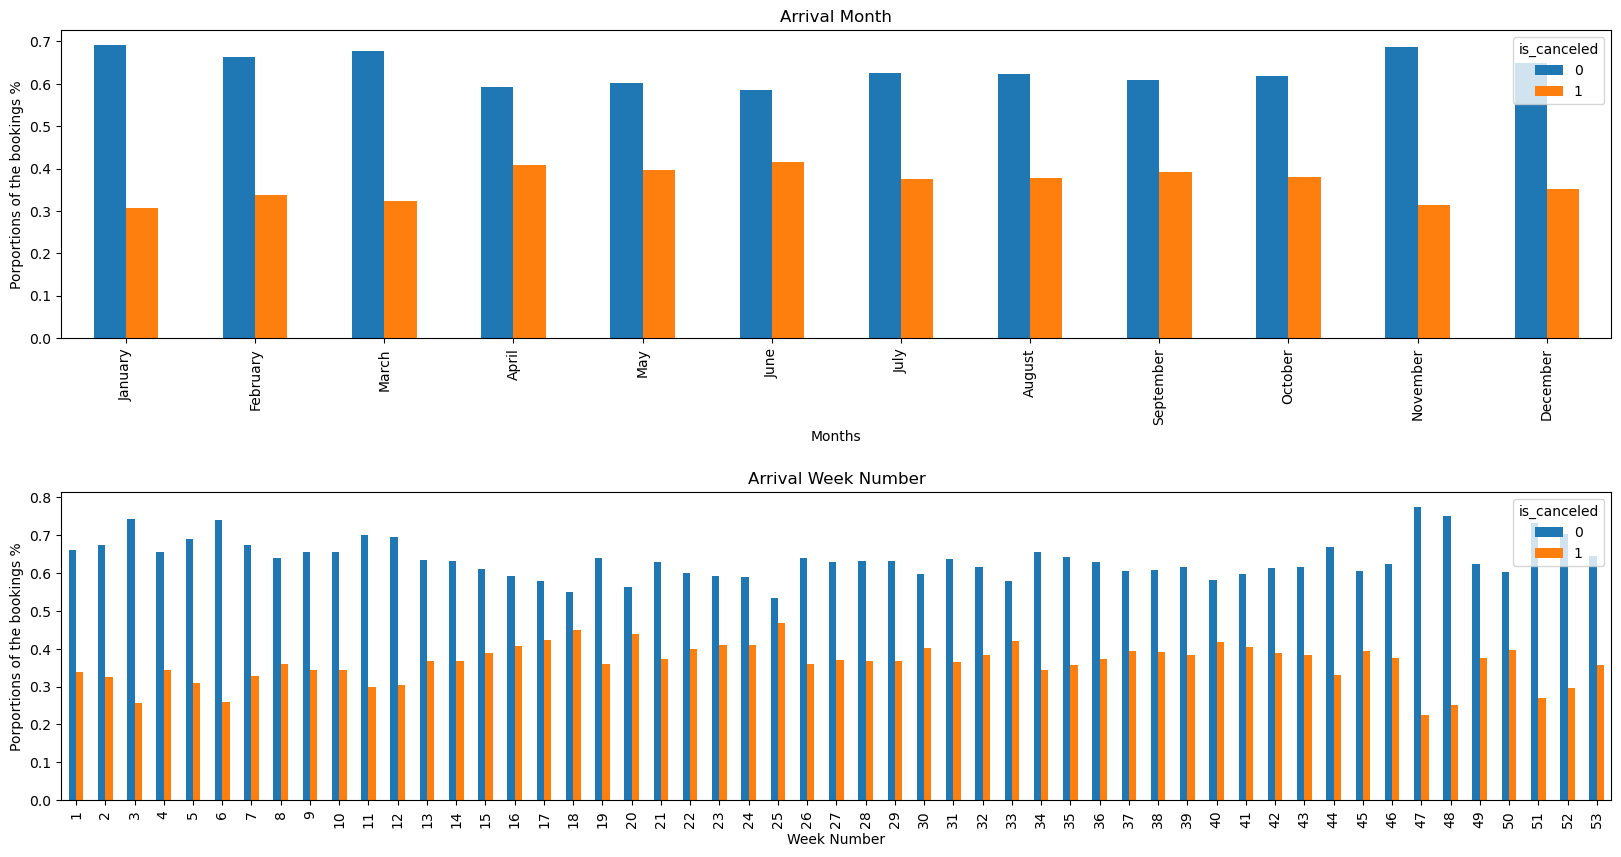

In [6]:
fig, ax = plt.subplots(2,1,figsize = (20,10))

plt.subplots_adjust(hspace=0.5)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
pd.crosstab(df['arrival_date_month'],df['is_canceled'],normalize='index').reindex(month_order).plot(kind='bar',ax = ax[0])
pd.crosstab(df['arrival_date_week_number'],df['is_canceled'],normalize='index').plot(kind='bar',ax = ax[1])

ax[0].set_title("Arrival Month")
ax[0].set_xlabel("Months")
ax[0].set_ylabel("Porportions of the bookings %")

ax[1].set_title("Arrival Week Number")
ax[1].set_xlabel("Week Number")
ax[1].set_ylabel("Porportions of the bookings %")

plt.show()

## Notes

Business pov:

* Bookings are not affected by months or the week number. They stay relatively stable, and there may be a few weeks or a few months where the cancellation rate is higher than the norm

Modelling pov:

* Both features share the same insight; however, months is broader, whereas week is granular. Infering to remove the months feature and retain week feature to aid with dimensionality 

## arrival_date_day_of_month

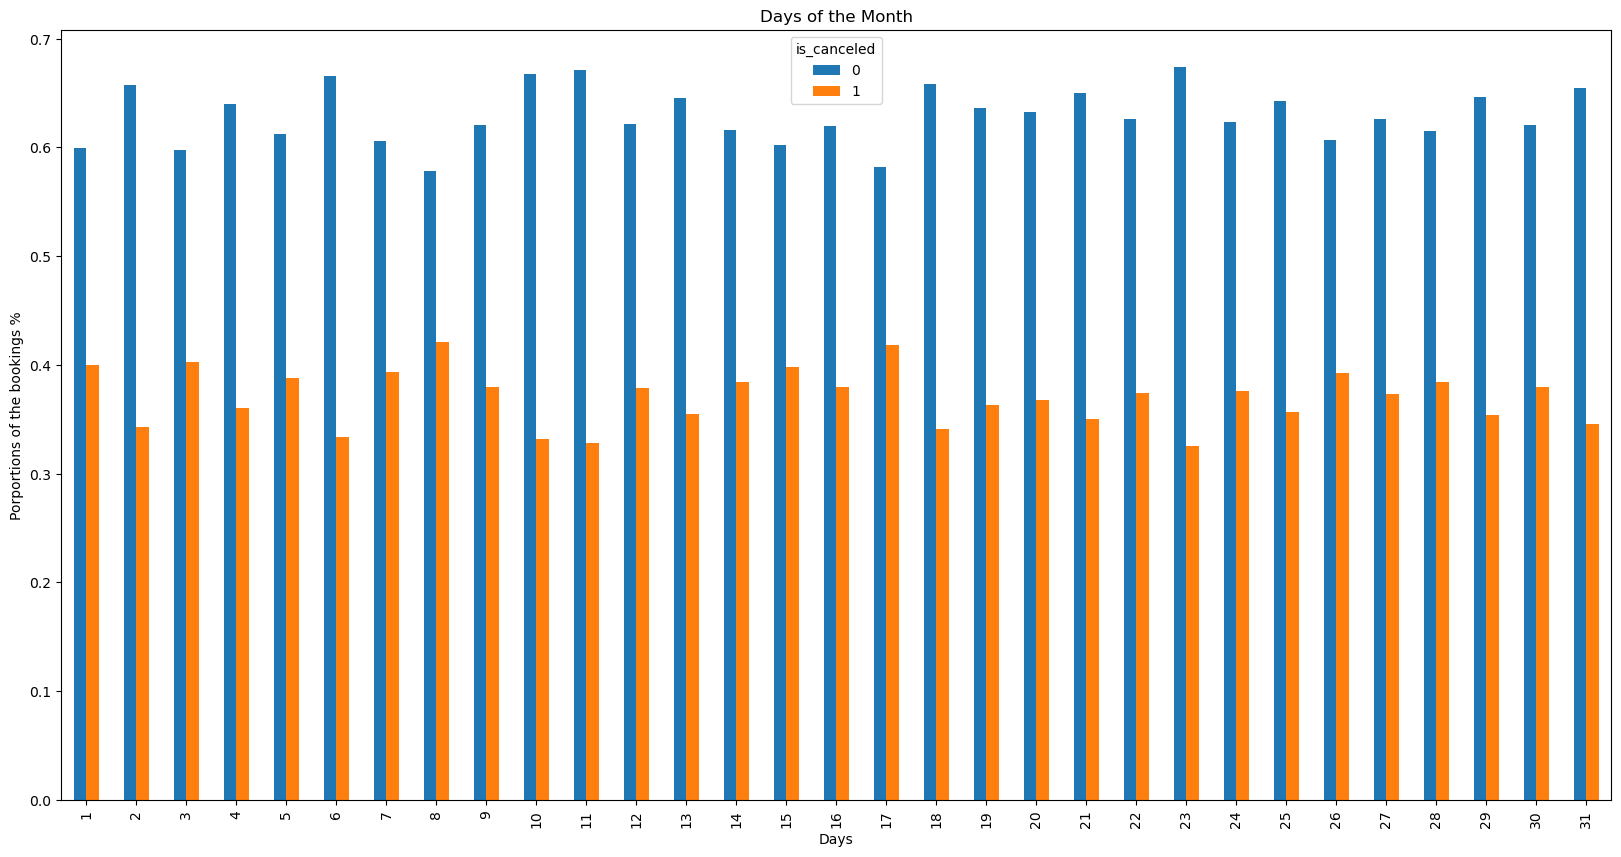

In [7]:
fig, ax = plt.subplots(figsize = (20,10))

pd.crosstab(df['arrival_date_day_of_month'],df['is_canceled'],normalize='index').plot(kind='bar',ax = ax)

ax.set_title("Days of the Month")
ax.set_xlabel("Days")
ax.set_ylabel("Porportions of the bookings %")

plt.show()

## Notes

Business pov:

* Cancellation behaviour appears relatively stable across the days of the month. Not a particular day stands out. Suggesting, no concerns regarding the days

Modelling pov:

* The cancellation proportions are heavily homogeneous. Though not clear for predictive signal or how good the feature actually is for the modelling. For instance,  it may resemble a balanced feature, but it actually be a rubbish feature 

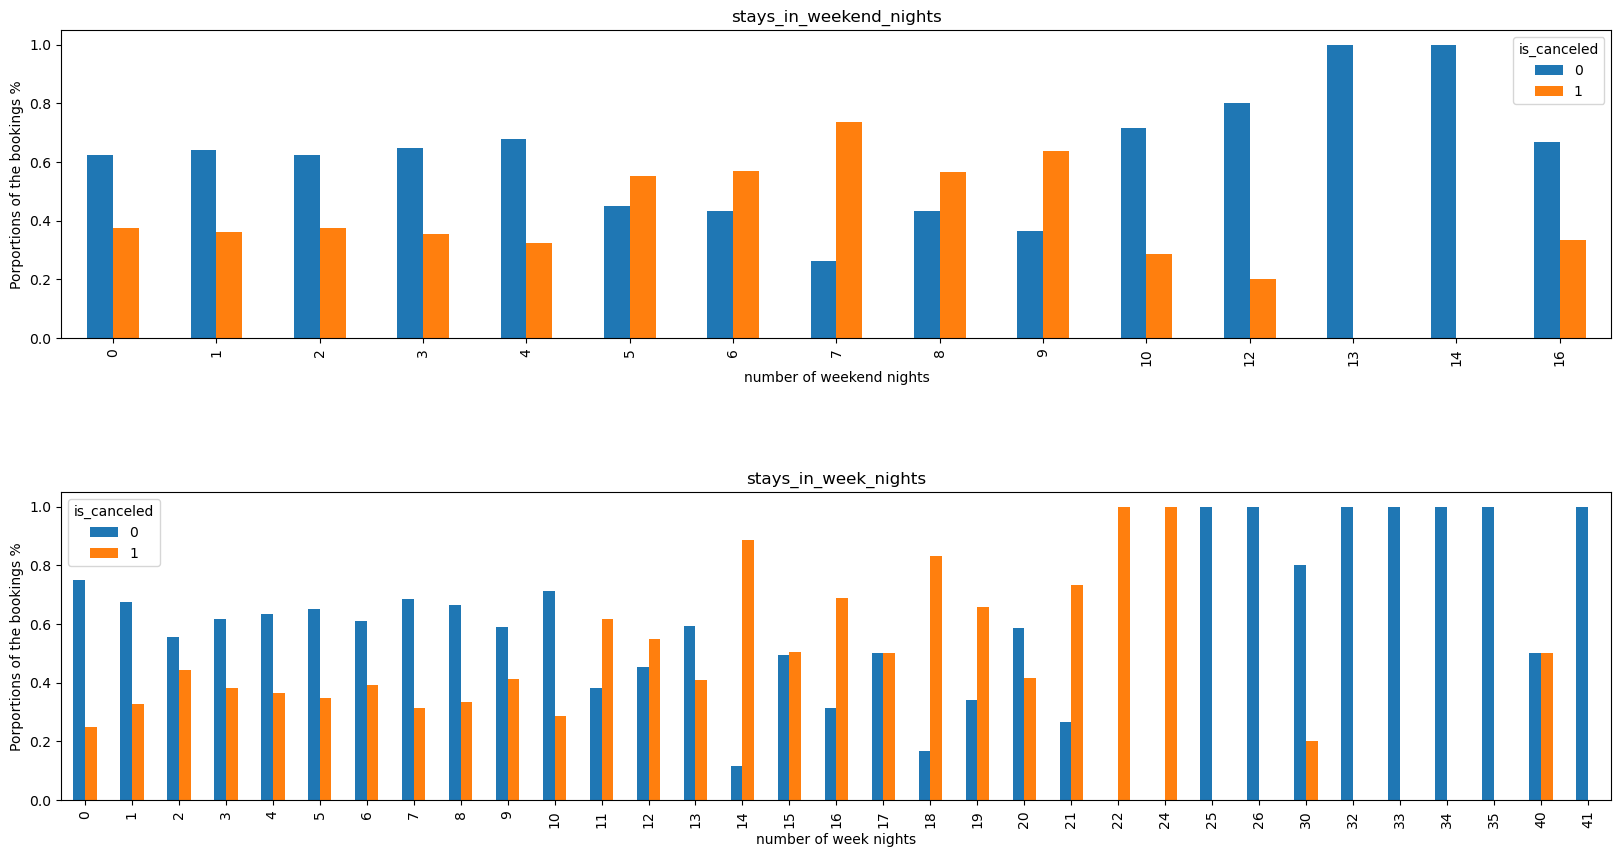

In [8]:
fig, ax = plt.subplots(2,1,figsize = (20,10))

plt.subplots_adjust(hspace=0.5)

pd.crosstab(df['stays_in_weekend_nights'],df['is_canceled'],normalize='index').plot(kind='bar',ax = ax[0])
pd.crosstab(df['stays_in_week_nights'],df['is_canceled'],normalize='index').plot(kind='bar',ax = ax[1])

ax[0].set_title("stays_in_weekend_nights")
ax[0].set_xlabel("number of weekend nights")
ax[0].set_ylabel("Porportions of the bookings %")

ax[1].set_title("stays_in_week_nights")
ax[1].set_xlabel("number of week nights")
ax[1].set_ylabel("Porportions of the bookings %")

plt.show()

## Notes

Business pov:

*  long weekend/week nights cancellation rate tends to be little to none, in contrast, shorter weekend/week nights cancellation rate are more common. However, in the middle cancellation rates are through the roof. 
Modelling pov:

* both share the same insight, best to merge them together to form a new feature called total stay, or remove one feature to help with dimensionality 

## Children/Adults/Babies

In [9]:
pd.crosstab(df['children'],df['is_canceled'],normalize='index')

is_canceled,0,1
children,,
0.0,0.628106,0.371894
1.0,0.676974,0.323026
2.0,0.577808,0.422192
3.0,0.776316,0.223684
10.0,0.000000,1.000000


In [10]:
pd.crosstab(df['children'] > 0,df['is_canceled'],normalize='index')

is_canceled,0,1
children,,
False,0.628106,0.371894
True,0.635579,0.364421


In [11]:
pd.crosstab(df['babies'],df['is_canceled'],normalize='index')

is_canceled,0,1
babies,,
0,0.627184,0.372816
1,0.816258,0.183742
2,0.857143,0.142857
9,1.000000,0.000000
10,1.000000,0.000000


In [12]:
pd.crosstab(df['adults'],df['is_canceled'],normalize='index')

is_canceled,0,1
adults,,
0,0.748092,0.251908
1,0.707104,0.292896
2,0.606532,0.393468
3,0.653058,0.346942
4,0.741935,0.258065
5,0.000000,1.000000
6,0.000000,1.000000
10,0.000000,1.000000
20,0.000000,1.000000


In [13]:
pd.crosstab(df['adults'],df['is_canceled'])

is_canceled,0,1
adults,,
0,294,99
1,16076,6659
2,54281,35213
3,4047,2150
4,46,16
5,0,2
6,0,1
10,0,1
20,0,2


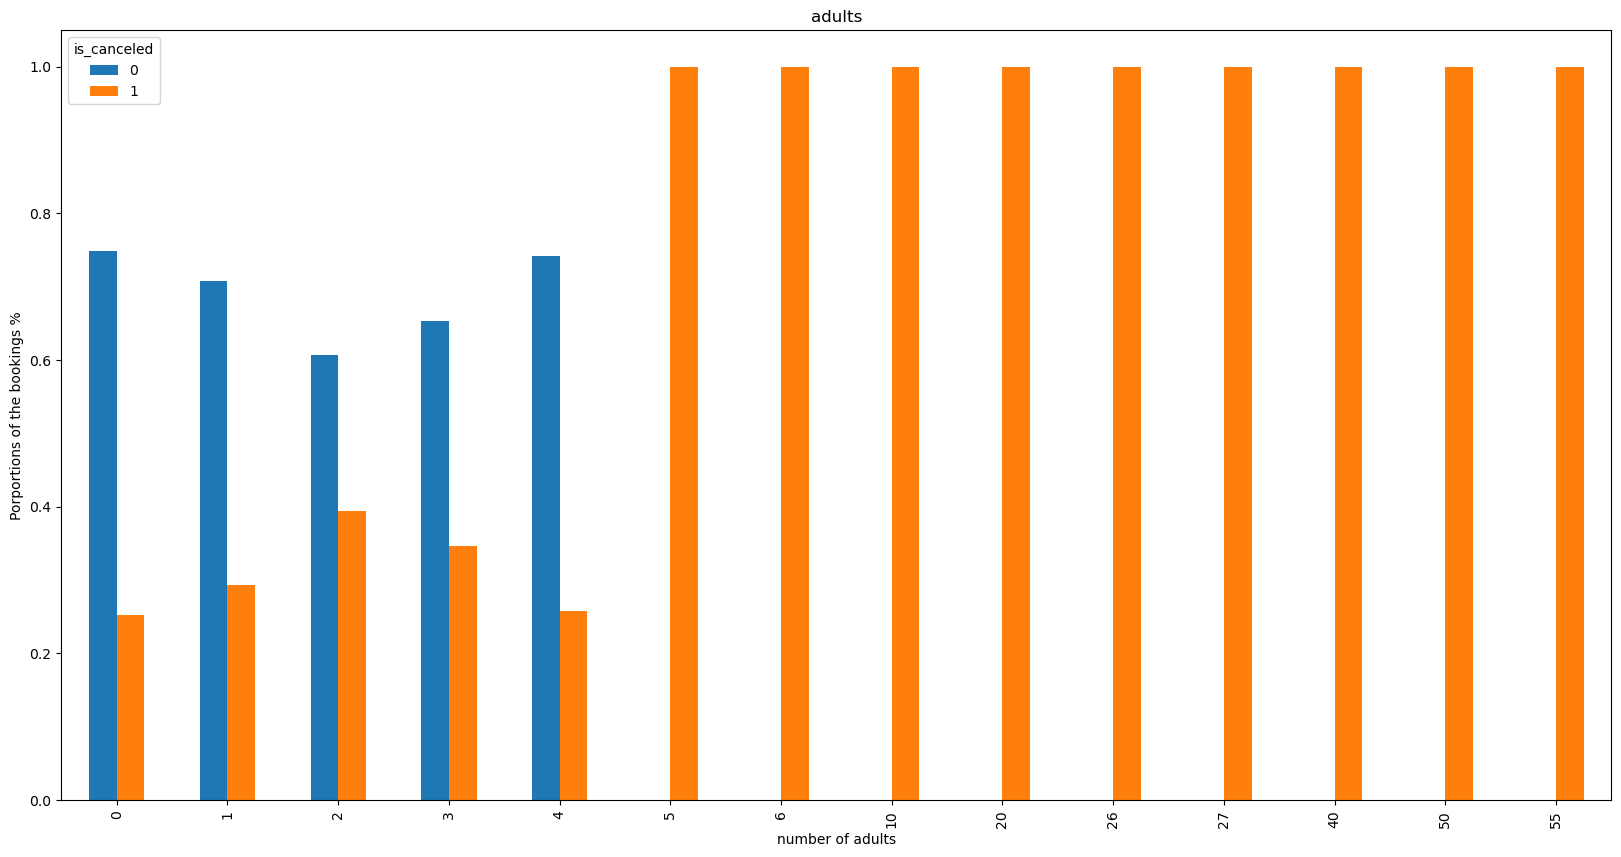

In [14]:
fig, ax = plt.subplots(figsize = (20,10))

plt.subplots_adjust(hspace=0.5)

pd.crosstab(df['adults'],df['is_canceled'],normalize='index').plot(kind='bar',ax = ax)

ax.set_title("adults")
ax.set_xlabel("number of adults")
ax.set_ylabel("Porportions of the bookings %")

plt.show()

## Notes (COME BACK TO THIS)

* Previously, from the univariate analysis, we are well aware that babies and children primarily consist of heavily concentrated 0 values (No Babies/Children)

Business Pov:

* Most of bookings are made up of no children or babies
* Most bookings are primarily two adults
* Anything over 5 adults (inclusively) results in permanent cancellation
* Anything less than 5 (exclusively) illustrates a fairer cancellation rate 

# Meal

In [15]:
pd.crosstab(df['meal'],df['is_canceled'],normalize=True) * 100

is_canceled,0,1
meal,,
BB,48.286332,28.976341
FB,0.269141,0.402029
HB,7.949738,4.189340
No meal,0.739295,0.240544
SC,5.619990,3.327250


In [16]:
pd.crosstab(df['meal'],df['is_canceled'],normalize='index')

is_canceled,0,1
meal,,
BB,0.624963,0.375037
FB,0.401003,0.598997
HB,0.654888,0.345112
No meal,0.754506,0.245494
SC,0.628126,0.371874


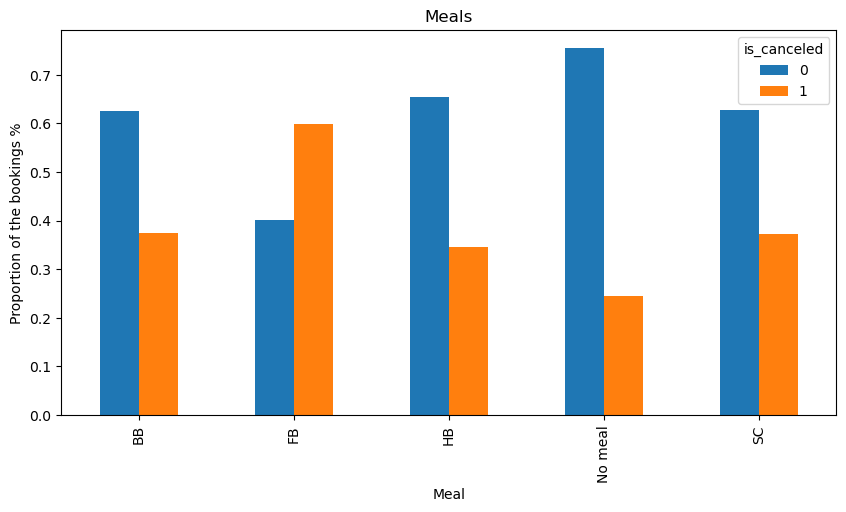

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

pd.crosstab(df['meal'],df['is_canceled'],normalize='index').plot(kind='bar', ax = ax)

ax.set_title('Meals')
ax.set_xlabel('Meal')
ax.set_ylabel('Proportion of the bookings %')

plt.show()

## Notes

Business pov:

*  BB, HB, SC shares similar cancellation rates

*  FB shares the most cancellation rates. It has more cancellations than non-cancellations

*  No meals is the only category that is prevalent with the most non-cancellations

Modelling pov:

* 3 categories does not show strong predictive signal, they all share the same cancellation rate
* No meal and FB shows strong predictive signal, they highly differ from the avg cancellation rate 

## Country

In [20]:
df['country'].value_counts().head(20)

country
PRT    48585
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
USA     2097
CHE     1730
CN      1279
AUT     1263
SWE     1024
CHN      999
POL      919
ISR      669
RUS      632
NOR      607
Name: count, dtype: int64

In [19]:
df['country'].value_counts().head(20).index

Index(['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'BRA', 'NLD',
       'USA', 'CHE', 'CN', 'AUT', 'SWE', 'CHN', 'POL', 'ISR', 'RUS', 'NOR'],
      dtype='str', name='country')

In [21]:
top20

Index(['PRT', 'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'BRA', 'NLD',
       'USA', 'CHE', 'CN', 'AUT', 'SWE', 'CHN', 'POL', 'ISR', 'RUS', 'NOR'],
      dtype='str', name='country')

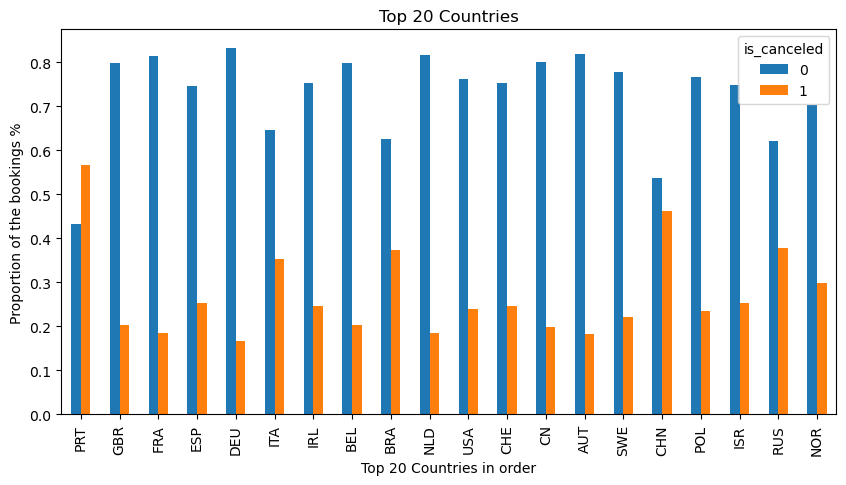

In [49]:
fig, ax = plt.subplots(figsize=(10,5))

top20 = df['country'].value_counts().head(20).index

countries = pd.crosstab(
    df[df['country'].isin(top20)]['country'],
    df[df['country'].isin(top20)]['is_canceled'],
    normalize='index'
).reindex(top20)

countries.plot(kind='bar', ax=ax)

ax.set_title('Top 20 Countries')
ax.set_xlabel('Top 20 Countries in order')
ax.set_ylabel('Proportion of the bookings %')

plt.show()

## Notes

Business pov:

*  PRT the only country in top 20 that has more cancellations than successful bookings

*  Most countries in top 20 have successful bookings


Modelling pov:

* dimensionality

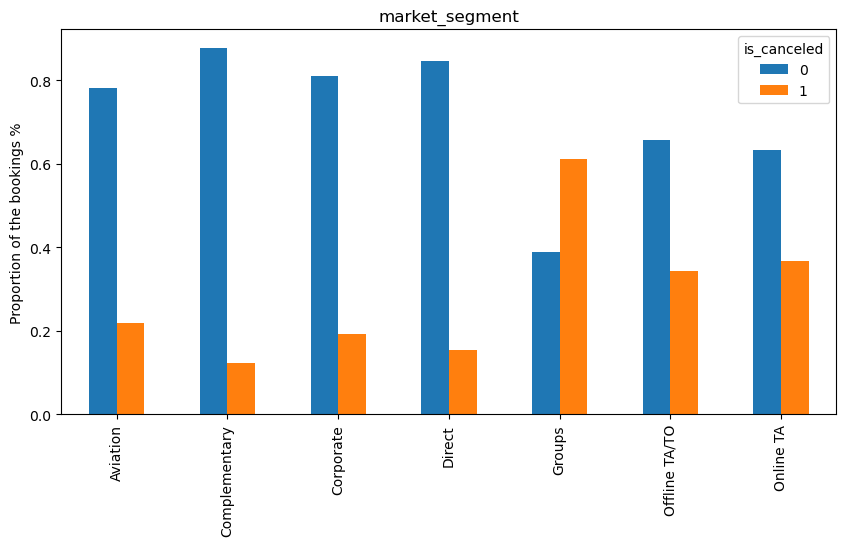

In [50]:
fig,  ax = plt.subplots(figsize=(10,5))

pd.crosstab(df['market_segment'],df['is_canceled'], normalize='index').plot(kind='bar', ax = ax)

ax.set_title('market_segment')
ax.set_ylabel('Proportion of the bookings %')
ax.set_xlabel(None)
plt.show()

## Notes

Business pov:

*  
Modelling pov:

* 

# is_repeated_guest

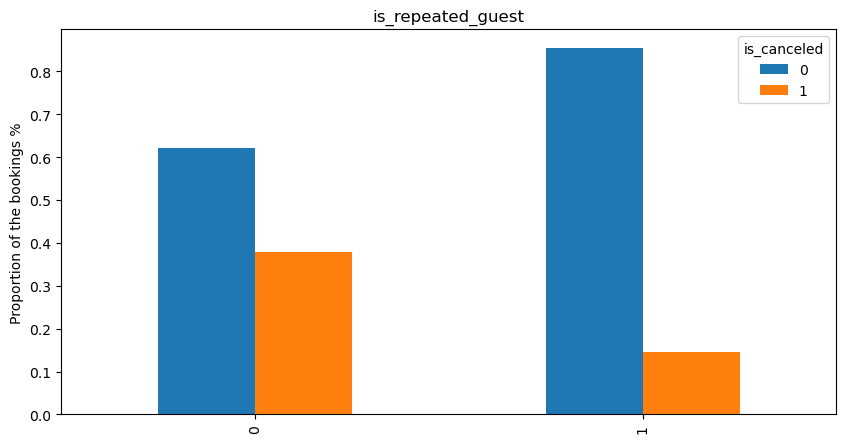

In [51]:
fig,  ax = plt.subplots(figsize=(10,5))

pd.crosstab(df['is_repeated_guest'],df['is_canceled'], normalize='index').plot(kind='bar', ax = ax)

ax.set_title('is_repeated_guest')
ax.set_ylabel('Proportion of the bookings %')
ax.set_xlabel(None)
plt.show()

# reserved / assigned_room_type

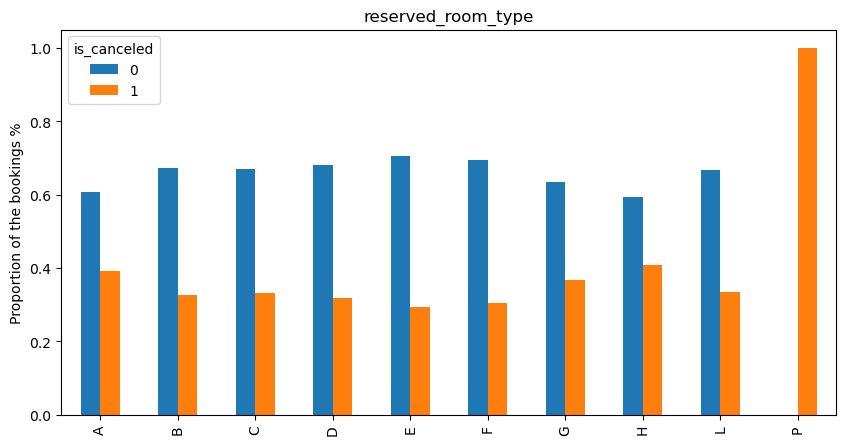

In [54]:
fig,  ax = plt.subplots(figsize=(10,5))

pd.crosstab(df['reserved_room_type'],df['is_canceled'], normalize='index').plot(kind='bar', ax = ax)

ax.set_title('reserved_room_type')
ax.set_ylabel('Proportion of the bookings %')
ax.set_xlabel(None)
plt.show()

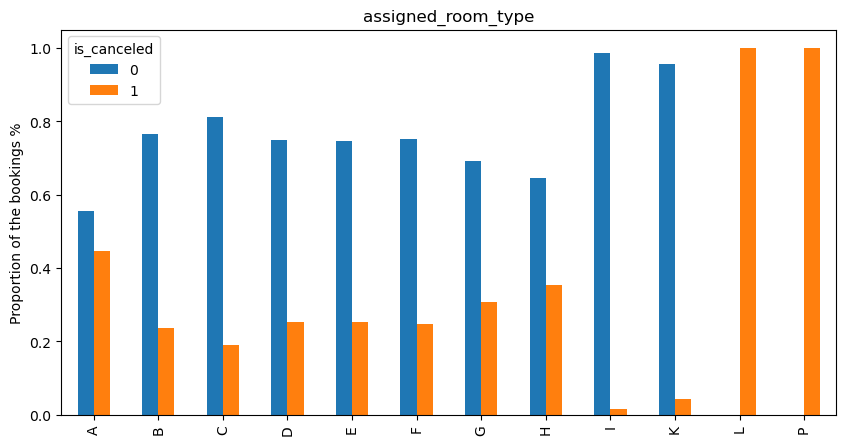

In [53]:
fig,  ax = plt.subplots(figsize=(10,5))

pd.crosstab(df['assigned_room_type'],df['is_canceled'], normalize='index').plot(kind='bar', ax = ax)

ax.set_title('assigned_room_type')
ax.set_ylabel('Proportion of the bookings %')
ax.set_xlabel(None)
plt.show()

# deposit_type

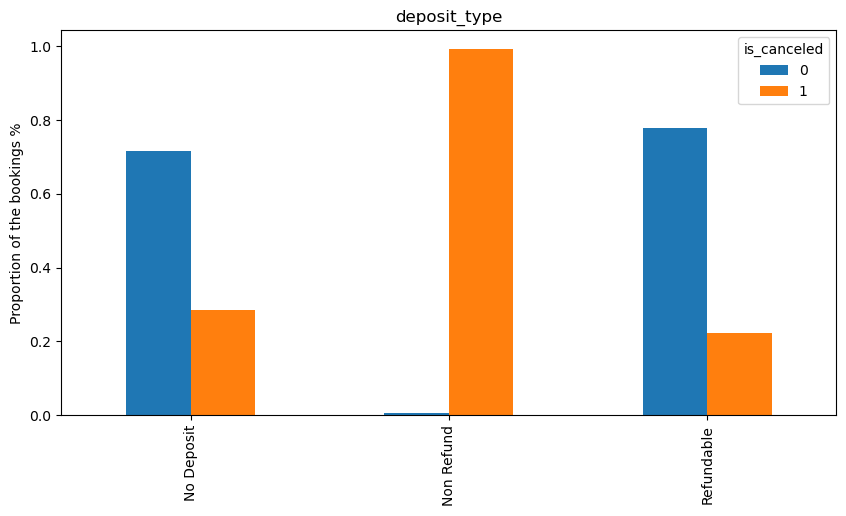

In [55]:
fig,  ax = plt.subplots(figsize=(10,5))

pd.crosstab(df['deposit_type'],df['is_canceled'], normalize='index').plot(kind='bar', ax = ax)

ax.set_title('deposit_type')
ax.set_ylabel('Proportion of the bookings %')
ax.set_xlabel(None)
plt.show()

# adr

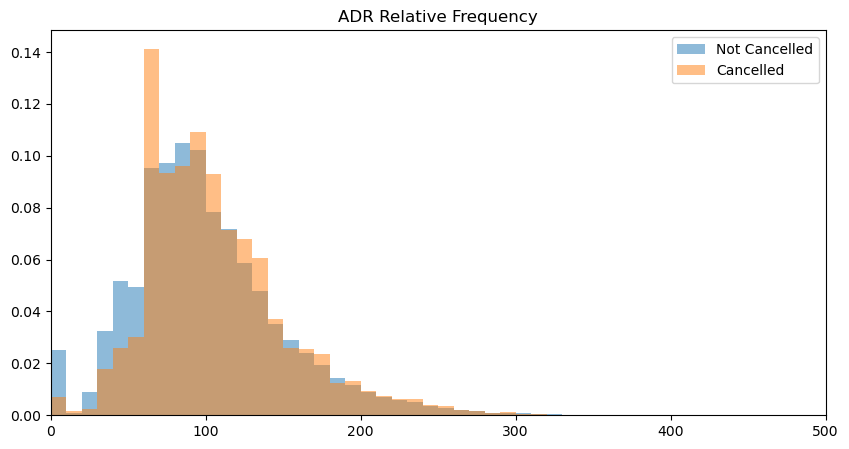

In [31]:
fig, ax = plt.subplots(figsize=(10,5))

not_cancelled = df[df['is_canceled']==0]['adr']
cancelled = df[df['is_canceled']==1]['adr']

bins = np.linspace(0, 500, 51)

ax.hist(
    not_cancelled,
    bins=bins,
    weights=np.ones_like(not_cancelled) / len(not_cancelled),
    alpha=0.5,
    label='Not Cancelled'
)

ax.hist(
    cancelled,
    bins=bins,
    weights=np.ones_like(cancelled) / len(cancelled),
    alpha=0.5,
    label='Cancelled'
)

ax.legend()
ax.set_title('ADR Relative Frequency')
ax.set_xlim(0, 500)
plt.show()

In [21]:
540/5

108.0

In [13]:
df[df['adr'] < 0]['adr']

14529   -6.38
Name: adr, dtype: float64

In [20]:
df[df['is_canceled'] == 1]['adr'].sort_values(ascending=False)

48032     5400.0
13129      450.0
13378      437.0
13310      392.0
13393      388.0
           ...  
109787       0.0
93895        0.0
93893        0.0
93887        0.0
93903        0.0
Name: adr, Length: 44153, dtype: float64

In [19]:
df[df['is_canceled'] == 0]['adr'].sort_values(ascending=False)

110910    510.00
14643     508.00
103419    451.50
38690     426.25
39103     402.00
           ...  
124         0.00
97270       0.00
78608       0.00
1006        0.00
14529      -6.38
Name: adr, Length: 74744, dtype: float64

# total_of_special_requests

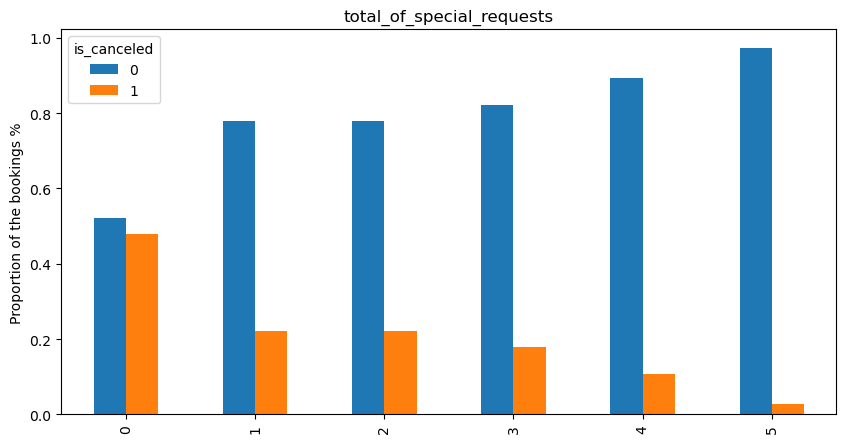

In [61]:
fig,  ax = plt.subplots(figsize=(10,5))

pd.crosstab(df['total_of_special_requests'],df['is_canceled'], normalize='index').plot(kind='bar', ax = ax)

ax.set_title('total_of_special_requests')
ax.set_ylabel('Proportion of the bookings %')
ax.set_xlabel(None)
plt.show()